# 03. 평가 & 개선 분석 — NASA C-MAPSS FD001 (Step 05)

**목적:** Step 04 모델의 한계(FNR=0.28)를 분석하고 개선 방향을 도출한다. 새 모델을 많이 추가하지 않고, RandomForest/GradientBoosting 중심으로 깊게 분석한다.

**분석 항목**
1. threshold별 조기경보 성능 (실제 위험 = true RUL≤30, 예측 위험 = pred RUL≤threshold)
2. False Negative 엔진 분석 (왜 놓쳤는가)
3. 예측 오차 분석 (잔차, 과대/과소 예측, 고장임박 구간 오차)

> 핵심 원칙: Recall만 보지 않고 Precision·FP 증가도 함께 본다. 예지보전에서 FN(놓침) 비용이 FP(과잉정비)보다 크다는 점을 해석에 반영한다. 현재 모델을 현장 적용 가능하다고 과장하지 않는다.


## 1. 셋업 및 분석 실행

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from evaluation_analysis import run_evaluation_analysis, ACTUAL_RISK
from preprocess import RUL_CAP

sns.set_theme(style="whitegrid")
R = run_evaluation_analysis(ROOT)
y_true = R["y_true"]; preds = R["preds"]; test_last = R["test_last"]


## 2. threshold별 조기경보 성능

예측 위험 임계값(predicted RUL ≤ threshold)을 30 → 60으로 높이면, 실제 고장임박(true RUL≤30) 엔진을 더 많이 잡아 Recall↑·FNR↓ 하지만, 정상 엔진까지 경보로 잡아 Precision↓·FP↑ 한다.


In [2]:
print("RandomForest"); display(R["threshold_RandomForest"])
print("GradientBoosting"); display(R["threshold_GradientBoosting"])


RandomForest


,threshold,Precision,Recall,F1,FNR,TP,FP,FN,TN
0,30,0.947,0.72,0.818,0.28,18,1,7,74
1,40,0.909,0.80,0.851,0.20,20,2,5,73
2,50,0.778,0.84,0.808,0.16,21,6,4,69
3,60,0.676,0.92,0.780,0.08,23,11,2,64


GradientBoosting


,threshold,Precision,Recall,F1,FNR,TP,FP,FN,TN
0,30,1.000,0.72,0.837,0.28,18,0,7,75
1,40,0.909,0.80,0.851,0.20,20,2,5,73
2,50,0.724,0.84,0.778,0.16,21,8,4,67
3,60,0.667,0.88,0.759,0.12,22,11,3,64


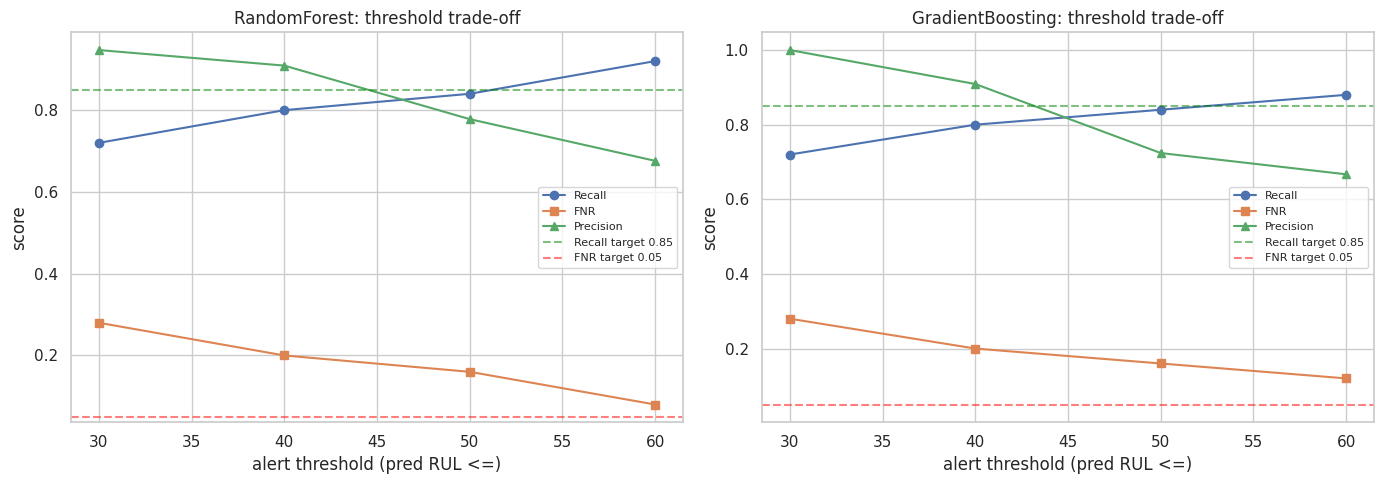

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m in zip(axes, ["RandomForest", "GradientBoosting"]):
    t = R[f"threshold_{m}"]
    ax.plot(t["threshold"], t["Recall"], "o-", label="Recall")
    ax.plot(t["threshold"], t["FNR"], "s-", label="FNR")
    ax.plot(t["threshold"], t["Precision"], "^-", label="Precision")
    ax.axhline(0.85, color="green", ls="--", alpha=0.5, label="Recall target 0.85")
    ax.axhline(0.05, color="red", ls="--", alpha=0.5, label="FNR target 0.05")
    ax.set_title(f"{m}: threshold trade-off")
    ax.set_xlabel("alert threshold (pred RUL <=)"); ax.set_ylabel("score"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 3. False Negative 엔진 분석 (threshold=30 기준)

놓친 엔진들이 어떤 특성을 가지는지 본다. true RUL은 위험(≤30)인데 예측이 안전(>30)으로 나온 엔진들이다.


In [4]:
fn = R["fn_RandomForest"]
print(f"FN 엔진 수 (RandomForest, threshold=30): {len(fn)}")
display(fn)

print("수명 구간 분포:")
display(fn["life_group"].value_counts())


FN 엔진 수 (RandomForest, threshold=30): 7


,engine_id,true_RUL,pred_RUL,error(pred-true),last_obs_cycle,est_total_life,life_group
0,18,28,67.6,39.6,133,161,short
1,37,21,58.3,37.3,121,142,short
2,41,18,66.8,48.8,123,141,short
3,53,26,34.6,8.6,164,190,mid
4,61,21,50.1,29.1,159,180,short
5,64,28,48.8,20.8,168,196,mid
6,90,28,35.0,7.0,146,174,short


수명 구간 분포:


life_group
short    5
mid      2
Name: count, dtype: int64

**관찰:** FN 엔진은 대부분 수명이 짧은(short-life) 엔진이고, 예측 RUL이 실제보다 크게 높다(과대 예측 = 위험 방향). 짧게 살고 일찍 고장나는 엔진의 마지막 시점 센서값이, 모델이 학습한 "평균적 열화 수준"보다 덜 진행된 것처럼 보이기 때문으로 해석된다.


## 4. 예측 오차 분석

예측 vs 실제 산점도에서 FN 엔진(빨간 X)을 표시한다. 대각선 위쪽 = 과대 예측(실제보다 길게 봄, 위험). 고장임박 구간(빨간 영역)에서 점이 위로 솟으면 놓칠 위험이 크다.


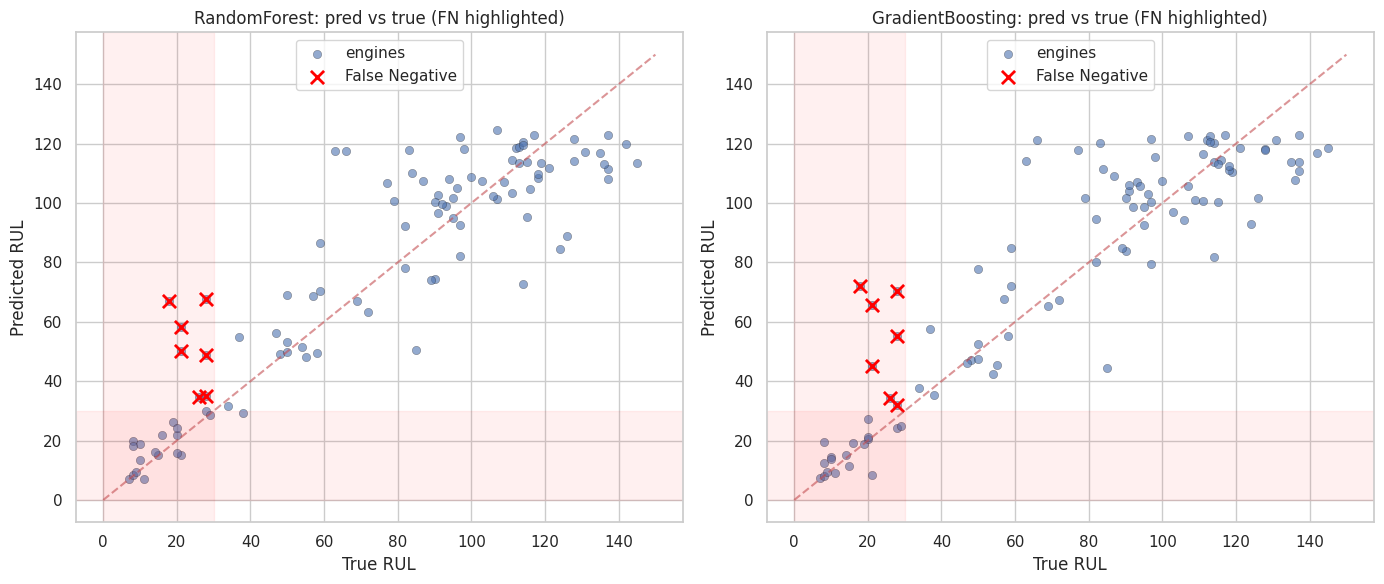

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, m in zip(axes, ["RandomForest", "GradientBoosting"]):
    p = preds[m]
    ax.scatter(y_true, p, alpha=0.6, edgecolor="k", linewidth=0.3, label="engines")
    fn_ids = set(R[f"fn_{m}"]["engine_id"])
    fn_idx = [i for i, e in enumerate(test_last["engine_id"]) if e in fn_ids]
    ax.scatter(np.array(y_true)[fn_idx], np.array(p)[fn_idx],
               color="red", marker="x", s=90, linewidth=2, label="False Negative")
    lim = [0, max(y_true.max(), RUL_CAP) + 5]
    ax.plot(lim, lim, "r--", alpha=0.6)
    ax.axhspan(0, ACTUAL_RISK, color="red", alpha=0.06)
    ax.axvspan(0, ACTUAL_RISK, color="red", alpha=0.06)
    ax.set_title(f"{m}: pred vs true (FN highlighted)")
    ax.set_xlabel("True RUL"); ax.set_ylabel("Predicted RUL"); ax.legend()
plt.tight_layout(); plt.show()


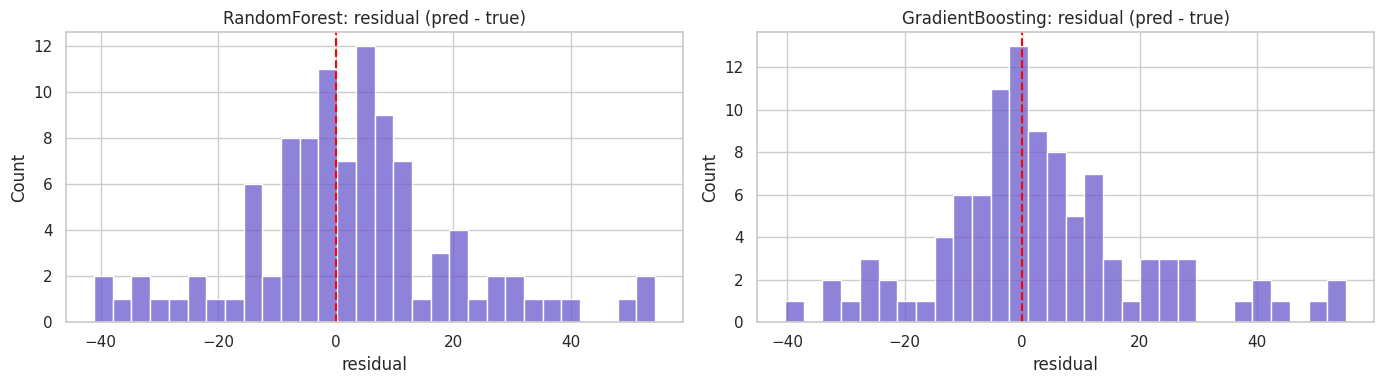

RandomForest {'n': 100, 'mean_residual': 2.41, 'over_pred_count': 56, 'under_pred_count': 43, 'alert_zone_mean_residual': 9.42, 'alert_zone_over_pred': 20, 'alert_zone_n': 25}
GradientBoosting {'n': 100, 'mean_residual': 3.15, 'over_pred_count': 53, 'under_pred_count': 47, 'alert_zone_mean_residual': 8.67, 'alert_zone_over_pred': 19, 'alert_zone_n': 25}


In [6]:
# 잔차 분포 (예측 - 실제). 양수 = 과대 예측(위험 방향)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, m in zip(axes, ["RandomForest", "GradientBoosting"]):
    resid = np.clip(preds[m], 0, RUL_CAP) - y_true
    sns.histplot(resid, bins=30, ax=ax, color="slateblue")
    ax.axvline(0, color="red", ls="--")
    ax.set_title(f"{m}: residual (pred - true)")
    ax.set_xlabel("residual"); 
plt.tight_layout(); plt.show()

for m in ["RandomForest", "GradientBoosting"]:
    print(m, R[f"resid_{m}"])


**관찰:** 고장임박 구간(true RUL≤30)에서 잔차 평균이 양수(과대 예측)다. 즉 모델은 위험한 엔진을 실제보다 안전하게 보는 경향이 있고, 이것이 FN의 직접 원인이다.


## 5. 개선 방향 요약

| 방향 | 기대 효과 | 트레이드오프 |
|---|---|---|
| threshold 상향(예: 50~60) | FNR↓, Recall↑ (즉시 적용 가능) | FP↑ (과잉 정비 증가) |
| 시계열 피처(이동평균·기울기) | 마지막 시점 과대 예측 완화 | 피처 엔지니어링 필요 |
| 모델 튜닝(목표=FNR/Recall) | 경계 구간 정확도 향상 | RMSE와 균형 필요 |

**비즈니스 해석:** FN(고장 임박 놓침) 비용이 FP(과잉 정비)보다 크므로, 안전 우선이면 threshold를 보수적으로(예: 50) 설정해 FNR을 낮추는 것이 합리적이다. 다만 이는 근본 해결이 아니라 운영 완충이며, 시계열 피처로 과대 예측 자체를 줄이는 것이 다음 핵심 과제다.

상세: `docs/05_evaluation_summary.md`
